In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
sys.path.append("/data/user/nlad/NNMFitStuff")


In [3]:
from utils.plot_utils import plot_hist_errorbar, plot_ratio_errorbar, initialize_figure, make_hist_error, make_hist2d_error, savefig

In [4]:
from utils.plot_utils import plot_hist_band, plot_ratio_band,plot_data_hist_errorbar, plot_data_ratio_errorbar,rolling_window

In [5]:
from utils.misc import find_nearest

### Using NNMFit's kde tools

In [6]:
from NNMFit.kde_tools.kde_utilities import KDEKernel

No cuda in path, using pykde


## Binning settings

In [7]:
# HESE Tracks
bins_cos = np.array(np.linspace(-1, 1, 11))

In [8]:
np.linspace(4.778, 7.1, 24)

array([4.778     , 4.87895652, 4.97991304, 5.08086957, 5.18182609,
       5.28278261, 5.38373913, 5.48469565, 5.58565217, 5.6866087 ,
       5.78756522, 5.88852174, 5.98947826, 6.09043478, 6.1913913 ,
       6.29234783, 6.39330435, 6.49426087, 6.59521739, 6.69617391,
       6.79713043, 6.89808696, 6.99904348, 7.1       ])

In [9]:
# extend bins towards lower energies
#binsize_logE = np.diff(np.linspace(3, 7, 23))[0]
binsize_logE = np.diff(np.linspace(4.778, 7.1, 24))[0]
binsize_logE

0.10095652173913017

In [10]:
additional_bins = np.array([4.778 - i * binsize_logE for i in range(2)])
additional_bins

array([4.778     , 4.67704348])

In [11]:
additional_bins = additional_bins[::-1]
additional_bins

array([4.67704348, 4.778     ])

In [12]:
bins_loge = np.concatenate([additional_bins[:-1], np.linspace(4.778, 7.1, 24)])
#bins_loge = np.linspace(4.778, 7.1, 24)
bins_loge

array([4.67704348, 4.778     , 4.87895652, 4.97991304, 5.08086957,
       5.18182609, 5.28278261, 5.38373913, 5.48469565, 5.58565217,
       5.6866087 , 5.78756522, 5.88852174, 5.98947826, 6.09043478,
       6.1913913 , 6.29234783, 6.39330435, 6.49426087, 6.59521739,
       6.69617391, 6.79713043, 6.89808696, 6.99904348, 7.1       ])

# Load dataframe sample

In [13]:
# HESE Tarcks
df = pd.read_parquet(
    "/data/ana/Diffuse/GlobalFit_Flavor/NNMFit_Datasets/WithoutDeepCore/SnowStorm_v2_HESE_Baseline_Tracks/dataset_HESE_Tracks.parquet"
)

In [14]:
df_muon = df[~np.isnan(df['MuonWeight'])]
#df_muon.keys()

In [15]:
# access variables
reco_energy = df_muon['reco_energy']
reco_zenith = df_muon['reco_dir']
weights = df_muon['MuonWeight']

In [18]:
df_muon[["reco_energy","MuonWeight"]]

reco_energy    MuonWeight
21315 16611   11   0  135715.258289  2.423983e-11
      64472   52   0  112868.685192  2.547179e-10
      64701   54   0  127510.311397  8.615306e-12
      67447   65   0  119960.345391  2.406330e-11
      81338   67   0  227458.026031  1.443391e-11
      109413  95   0   68089.295984  1.081641e-10
      161996  144  0   89956.202888  1.864528e-11
      211373  176  0   92265.873201  3.471168e-11
      217525  190  0   67255.562989  1.805386e-10
      279654  231  0  118324.105675  3.636869e-11
      314182  266  0   69906.172309  2.620939e-11
      322789  274  0  276682.850685  1.105748e-12
      329785  264  0   68560.202478  1.267553e-10
      359783  301  0   79887.274366  1.398028e-11
      459741  384  0  187568.650821  5.415715e-12
      464361  390  0  140769.260495  2.087522e-12
      489049  382  0  376688.511210  2.183380e-11
      490752  393  0  126757.896294  1.010536e-12
      544406  447  0  104331.260295  1.174268e-11
21316 1545811 2914 0  138938.652148  3.599342e-09

In [16]:
print("rate per year", sum(weights)*365*24*3600 )

rate per year 0.14235293184028458


## plot unweighted

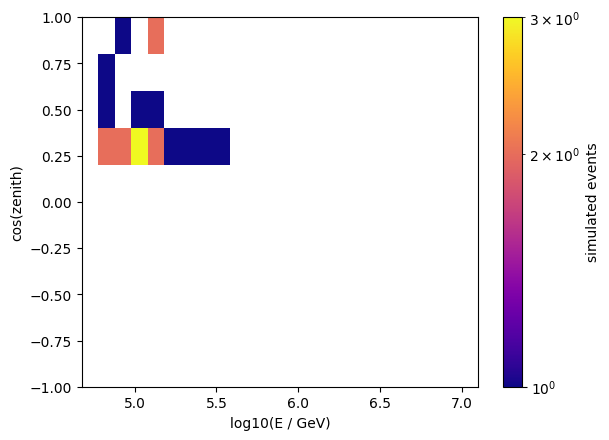

In [19]:
plt.figure()
h = plt.hist2d(
    np.log10(reco_energy),
    np.cos(reco_zenith),
    weights=None,
    bins=(bins_loge, bins_cos),
    norm=mpl.colors.LogNorm(),
cmap='plasma')

plt.colorbar(label='simulated events')
plt.xlabel('log10(E / GeV)')
plt.ylabel('cos(zenith)')
plt.show()

## plot Flux weighted

Sum of MC expectation
4.513981856934443e-09 Hz
0.14235293184028458 per year


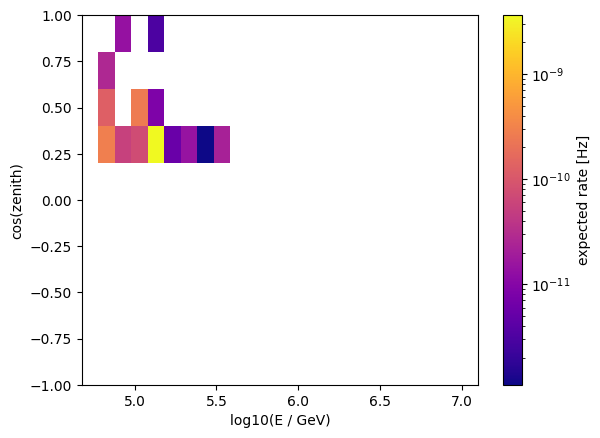

In [21]:
plt.figure()
h = plt.hist2d(
    np.log10(reco_energy),
    np.cos(reco_zenith),
    weights=weights,
    bins=(bins_loge, bins_cos),
norm=mpl.colors.LogNorm(),cmap='plasma')
print('Sum of MC expectation')
print(np.sum(h[0]), 'Hz')
print(np.sum(h[0])*365*24*3600, 'per year')

plt.colorbar(label='expected rate [Hz]')
plt.xlabel('log10(E / GeV)')
plt.ylabel('cos(zenith)')
plt.show()

# Try out smoothing with KDE

In [22]:
kde = KDEKernel.make_new_kernel(
    energy=reco_energy,
    zenith=reco_zenith,
    weights=weights,
    bounds=((4.5,7.1), (-1.1,1.2)),
    thresholds=((4.778,7), (-1, 1.1)),

    # default values from here
    useNevents=None,
    kde_values=None,
    use_cuda=False,
    niter=30,  # 10
    bootstrap=True,  # False
    adaptive=True,
    weight_adaptive_bw=True,  # False
    alpha=0.1,  # 0.3
    #bw_method="scott"  # "silverman"
     bw_method="silverman"  # "silverman"
)

kde2 = None

In [47]:
bins_loge_centers = np.diff(bins_loge) / 2. + bins_loge[0:-1]
bins_cos_centers = np.diff(bins_cos) / 2. + bins_cos[0:-1]

X, Y = np.meshgrid(bins_loge_centers, bins_cos_centers)
XYpos = np.vstack([X.ravel(), Y.ravel()])

kde_evaluated = kde.func_rate_density(XYpos)

rate = np.reshape(kde_evaluated[0].T, X.shape)
rate_error = np.reshape(kde_evaluated[1].T, X.shape)

sum(sum(rate))

2.6513687553070066e-07

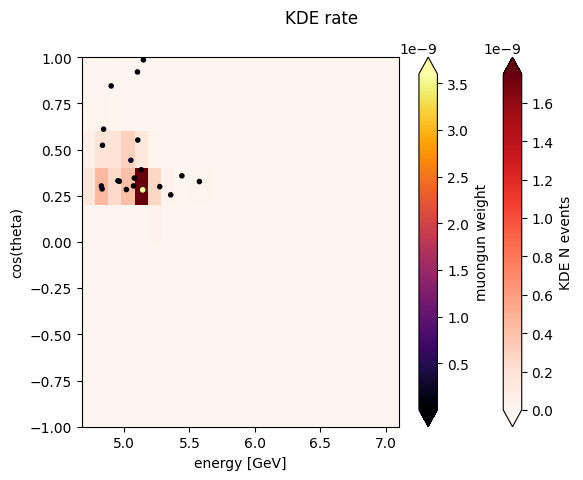

In [24]:
# new figure
fig, (ax1) = plt.subplots(1, 1)
fig.suptitle("KDE rate")

# plot
X_plot, Y_plot = np.meshgrid(bins_loge, bins_cos)
factor = weights.sum() / rate.sum()
pm = ax1.pcolormesh(X_plot, Y_plot, rate * factor, vmin=0, cmap="Reds")
plt.colorbar(pm, label="KDE N events", extend='both')

pc = ax1.scatter(
    x=np.log10(reco_energy),
    y=np.cos(reco_zenith),
    c=weights,
    cmap="inferno",
    marker="."
)
plt.colorbar(pc, label="muongun weight", extend='both')

# setup figure
ax1.set_xlabel("energy [GeV]")
ax1.set_ylabel("cos(theta)")
ax1.set_xlim(bins_loge[0], bins_loge[-1])
plt.show()

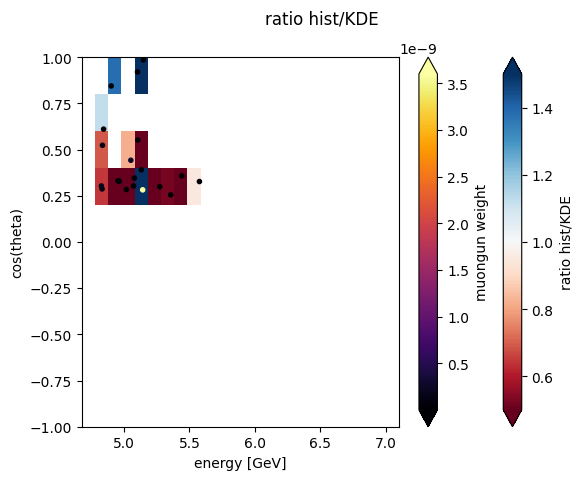

In [25]:
# new figure
fig, (ax1) = plt.subplots(1, 1)
fig.suptitle("ratio hist/KDE")

# muongun hist
hist, _, _ = np.histogram2d(
    np.log10(reco_energy),
    np.cos(reco_zenith),
    weights=weights,
    bins=(bins_loge, bins_cos),
)

# plot
X_plot, Y_plot = np.meshgrid(bins_loge, bins_cos)
ratio = hist.T / (rate * factor)
ratio[np.isclose(ratio, 0)] = np.NaN
pm = ax1.pcolormesh(X_plot, Y_plot, ratio, cmap="RdBu", vmin=0.5, vmax=1.5)
plt.colorbar(pm, label="ratio hist/KDE", extend='both')

pc = ax1.scatter(
    x=np.log10(reco_energy),
    y=np.cos(reco_zenith),
    c=weights,
    cmap="inferno",
    marker="."
)
plt.colorbar(pc, label="muongun weight", extend='both')

# setup figure
ax1.set_xlabel("energy [GeV]")
ax1.set_ylabel("cos(theta)")
ax1.set_xlim(bins_loge[0], bins_loge[-1])
plt.show()

In [26]:
if kde2 is not None:

    # new figure
    fig, (ax1) = plt.subplots(1, 1)
    fig.suptitle("ratio KDE2/KDE")

    # KDE2
    kde_evaluated2 = kde2.func_rate_density(XYpos)
    rate2 = np.reshape(kde_evaluated2[0].T, X.shape)
    rate_error2 = np.reshape(kde_evaluated2[1].T, X.shape)

    # plot
    X_plot, Y_plot = np.meshgrid(bins_loge, bins_cos)
    ratio = (rate2 * factor) / (rate * factor)
    ratio[np.isclose(ratio, 0)] = np.NaN
    pm = ax1.pcolormesh(X_plot, Y_plot, ratio, cmap="RdBu_r", vmin=0, vmax=2)
    plt.colorbar(pm, label="ratio hist/KDE", extend='both')

    pc = ax1.scatter(
        x=np.log10(reco_energy),
        y=np.cos(reco_zenith),
        c=weights,
        cmap="inferno",
        marker="."
    )
    plt.colorbar(pc, label="muongun weight", extend='both')

    # setup figure
    ax1.set_xlabel("energy [GeV]")
    ax1.set_ylabel("cos(theta)")
    ax1.set_xlim(bins_loge[0], bins_loge[-1])
    plt.show()

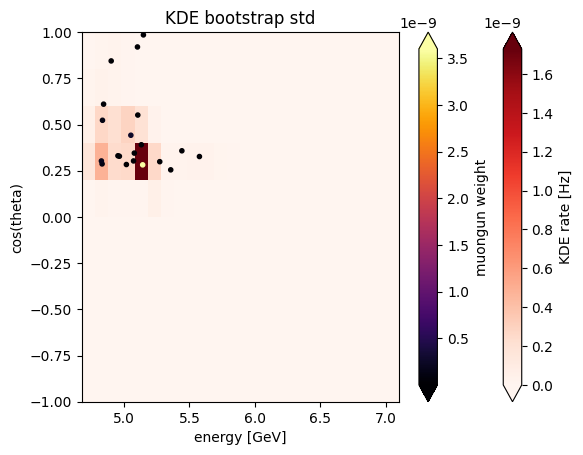

In [27]:
# new figure
fig, (ax1) = plt.subplots(1, 1)
ax1.set_title("KDE bootstrap std")

# plot
pm = ax1.pcolormesh(X_plot, Y_plot, rate_error * factor, cmap="Reds")
plt.colorbar(pm, label="KDE rate [Hz]", extend='both')

pc = ax1.scatter(
    x=np.log10(reco_energy),
    y=np.cos(reco_zenith),
    c=weights,
    cmap="inferno",
    marker="."
)
plt.colorbar(pc, label="muongun weight", extend='both')

# setup figure
ax1.set_xlabel("energy [GeV]")
ax1.set_ylabel("cos(theta)")
ax1.set_xlim(bins_loge[0], bins_loge[-1])
plt.show()

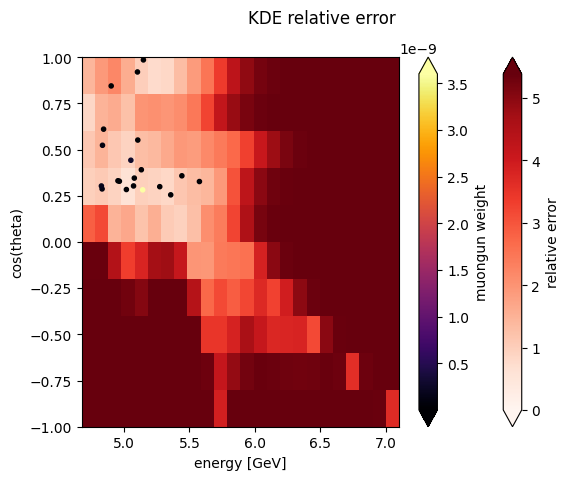

In [28]:
# new figure
fig, (ax1) = plt.subplots(1, 1)
fig.suptitle("KDE relative error")

# plot
pm = ax1.pcolormesh(X_plot, Y_plot, rate_error / rate, vmin=0,cmap="Reds")
plt.colorbar(pm, label="relative error", extend='both')

pc = ax1.scatter(
    x=np.log10(reco_energy),
    y=np.cos(reco_zenith),
    c=weights,
    cmap="inferno",
    marker="."
)
plt.colorbar(pc, label="muongun weight", extend='both')

# setup figure
ax1.set_xlabel("energy [GeV]")
ax1.set_ylabel("cos(theta)")
ax1.set_xlim(bins_loge[0], bins_loge[-1])
plt.show()

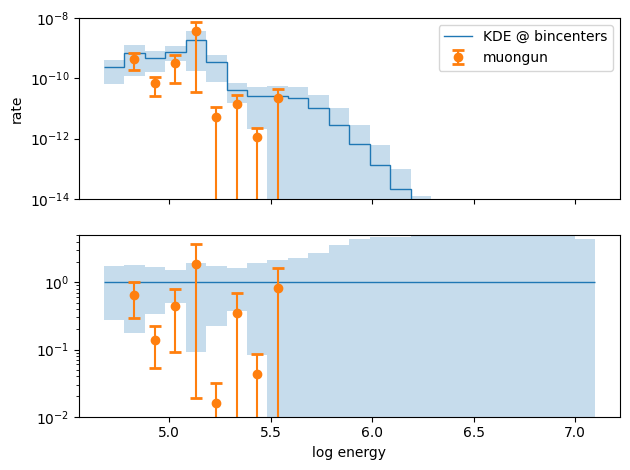

In [29]:
# new figure
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

# KDE
y = np.sum(rate*factor, axis=0)
yerror = np.sqrt(np.sum((rate_error*factor)**2, axis=0))
plot_hist_band(ax1, hist=y, bins=bins_loge, yerror=yerror, color="C0", label="KDE @ bincenters")
plot_ratio_band(ax2, hist=y, bins=bins_loge, yerror=yerror, hist_baseline=y, color="C0")

# muongun
hist, hist_error = make_hist_error(np.log10(reco_energy), bins=bins_loge, weights=weights)
plot_data_hist_errorbar(ax1, hist=hist, bins=bins_loge, yerror=hist_error, color="C1", label="muongun", marker="o")
plot_data_ratio_errorbar(ax2, hist=hist, bins=bins_loge, yerror=hist_error, hist_baseline=y, color="C1", marker="o")

ax1.legend()
plt.xlabel("log energy")
ax1.set_ylabel("rate")
ax1.set_yscale("log")
ax2.set_ylim(1e-2,5)
ax1.set_ylim(1e-14, 1e-8)

ax2.set_yscale("log")

# show
fig.tight_layout()
fig.subplots_adjust(hspace=0.2)
plt.show()

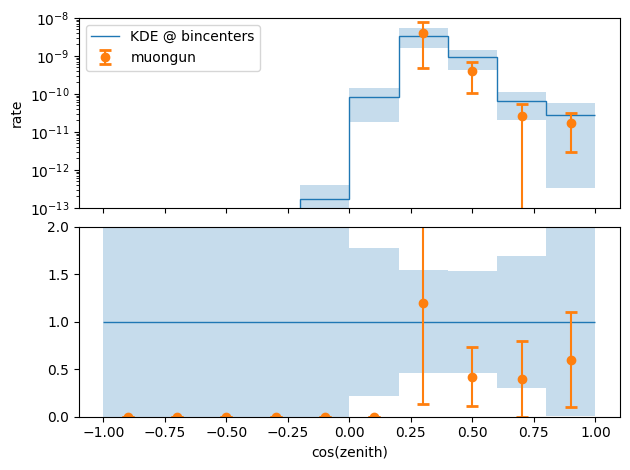

In [30]:
# new figure
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

# KDE
y = np.sum(rate*factor, axis=1)
yerror = np.sqrt(np.sum((rate_error*factor)**2, axis=1))
plot_hist_band(ax1, hist=y, bins=bins_cos, yerror=yerror, color="C0", label="KDE @ bincenters")
plot_ratio_band(ax2, hist=y, bins=bins_cos, yerror=yerror, hist_baseline=y, color="C0")

# print(np.cos(reco_zenith)[reco_energy>=1000.])
# muongun
# hist, hist_error = make_hist_error(np.cos(reco_zenith)[reco_energy>=1000.], bins=bins_cos, weights=weights[reco_energy>=1000.])
hist, hist_error = make_hist_error(np.cos(reco_zenith), bins=bins_cos, weights=weights)

plot_data_hist_errorbar(ax1, hist=hist, bins=bins_cos, yerror=hist_error, color="C1", label="muongun", marker="o")
plot_data_ratio_errorbar(ax2, hist=hist, bins=bins_cos, yerror=hist_error, hist_baseline=y, color="C1", marker="o")

ax1.legend()
plt.xlabel("cos(zenith)")
ax1.set_ylabel("rate")
ax1.set_yscale("log")
ax2.set_ylim(0, 2)
ax1.set_ylim(1e-13, 1e-8)

# show
fig.tight_layout()
fig.subplots_adjust(hspace=0.1)
plt.show()

In [31]:
# define analysis binning: cscd_cascade
bins_analysis_loge = np.linspace(4.778, 7.1, 24)
bins_analysis_cos = np.linspace(-1,1,11)

analysis_shape = (len(bins_analysis_loge) - 1, len(bins_analysis_cos) - 1)

bins_analysis_loge_centers = np.mean(rolling_window(bins_analysis_loge, 2), axis=1)
bins_analysis_cos_centers = np.mean(rolling_window(bins_analysis_cos, 2), axis=1)

In [32]:
# finer bining
# spline_binning_x = np.linspace(3, 7, 118)#67
spline_binning_x = np.linspace(4.67704348, 7.1, 49)#67

# spline_binning_y = np.linspace(-1,1, 31)
spline_binning_y = np.linspace(-1,1,21)


# ensure finer bins include analysis bin edges
assert all([np.any(np.isclose(v, spline_binning_x)) for v in bins_analysis_loge])
assert all([np.any(np.isclose(v, spline_binning_y)) for v in bins_analysis_cos])

spline_values_x = np.mean(rolling_window(spline_binning_x, 2), axis=1)
spline_values_y = np.mean(rolling_window(spline_binning_y, 2), axis=1)
spline_shape = (len(spline_values_x), len(spline_values_y))

# make grid for KDE
grid_x, grid_y = np.meshgrid(spline_values_x, spline_values_y)
grid_xy = np.vstack([grid_x.ravel(), grid_y.ravel()])

# eval KDE for spline
kde_evaluated_fine = kde.func_rate_density(grid_xy)
rate_fine = np.reshape(kde_evaluated_fine[0].T, grid_x.shape)
rate_error_fine = np.reshape(kde_evaluated_fine[1].T, grid_x.shape)

# renorm rate
rescale_factor = weights.sum() / rate_fine.sum()
rate_fine *= rescale_factor
rate_error_fine *= rescale_factor

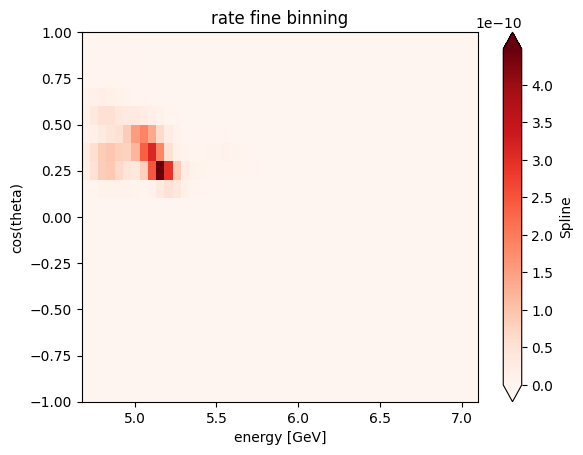

In [33]:
# new figure
fig, (ax1) = plt.subplots(1, 1)
ax1.set_title("rate fine binning")

# plot
X_plot, Y_plot = np.meshgrid(spline_binning_x, spline_binning_y)
pm = ax1.pcolormesh(X_plot, Y_plot, rate_fine, vmin=0, cmap="Reds")
plt.colorbar(pm, label="Spline", extend='both')

# setup figure
ax1.set_xlabel("energy [GeV]")
ax1.set_ylabel("cos(theta)")
ax1.set_xlim(bins_loge[0], bins_loge[-1])
plt.show()

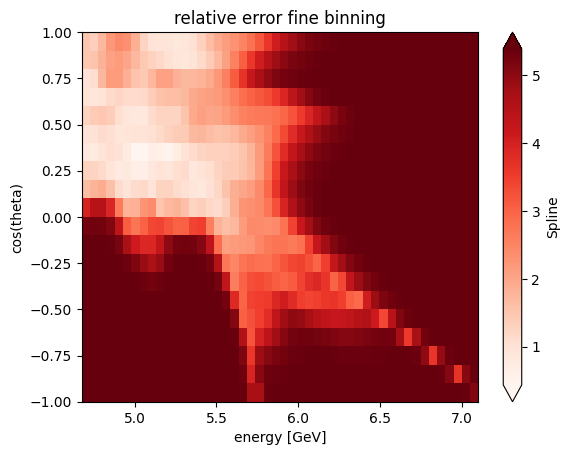

In [34]:
# new figure
fig, (ax1) = plt.subplots(1, 1)
ax1.set_title("relative error fine binning")

# plot
X_plot, Y_plot = np.meshgrid(spline_binning_x, spline_binning_y)
pm = ax1.pcolormesh(X_plot, Y_plot, rate_error_fine/rate_fine, cmap="Reds")
plt.colorbar(pm, label="Spline", extend='both')

# setup figure
ax1.set_xlabel("energy [GeV]")
ax1.set_ylabel("cos(theta)")
ax1.set_xlim(bins_loge[0], bins_loge[-1])
plt.show()

In [35]:
# sum up rate in anaylsis bins
integrated_rate = np.zeros(analysis_shape)
integrated_rate_error = np.zeros(analysis_shape)

# loop analysis bins
for idx_e, (emin, emax) in enumerate(rolling_window(bins_analysis_loge, 2)):
    for idx_z, (zmin, zmax) in enumerate(rolling_window(bins_analysis_cos, 2)):

        # get indices of fine bins within this analysis bin
        _, emin_idx = find_nearest(spline_binning_x, emin)
        _, emax_idx = find_nearest(spline_binning_x, emax)
        _, zmin_idx = find_nearest(spline_binning_y, zmin)
        _, zmax_idx = find_nearest(spline_binning_y, zmax)

        # build mask
        mask = np.zeros_like(rate_fine.T, dtype=bool)
        mask[emin_idx:emax_idx, zmin_idx:zmax_idx] = True

        integrated_rate[idx_e, idx_z] = np.sum(rate_fine.T[mask])        
        # integrated_rate_error[idx_e, idx_z] = np.sqrt(np.sum(rate_error_fine.T[mask]**2))

        # integrated_rate_error[idx_e, idx_z] = np.std(rate_fine.T[mask])
        # integrated_rate_error[idx_e, idx_z] = np.sqrt(np.mean(rate_error_fine.T[mask]**2))
        
        up = np.sum((rate_fine + rate_error_fine).T[mask])
        low = np.sum((rate_fine - rate_error_fine).T[mask])
        integrated_rate_error[idx_e, idx_z] = (up - low)


# rescale_factor = weights.sum() / integrated_rate.sum()
# integrated_rate *= rescale_factor
# integrated_rate_error *= rescale_factor

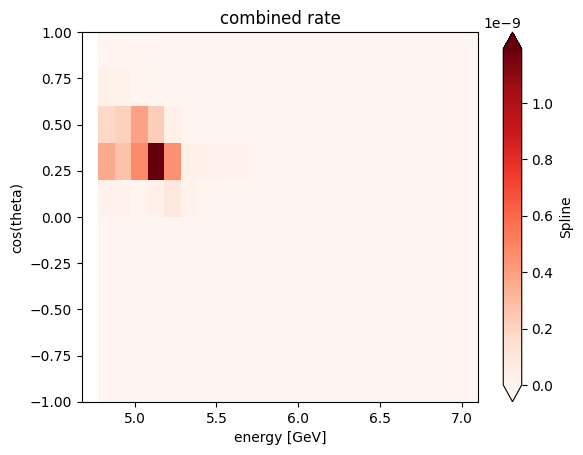

In [36]:
# new figure
fig, (ax1) = plt.subplots(1, 1)
ax1.set_title("combined rate")

# plot
X_plot, Y_plot = np.meshgrid(bins_analysis_loge, bins_analysis_cos)
pm = ax1.pcolormesh(X_plot, Y_plot, integrated_rate.T, cmap="Reds")
plt.colorbar(pm, label="Spline", extend='both')

# setup figure
ax1.set_xlabel("energy [GeV]")
ax1.set_ylabel("cos(theta)")
ax1.set_xlim(bins_loge[0], bins_loge[-1])
plt.show()

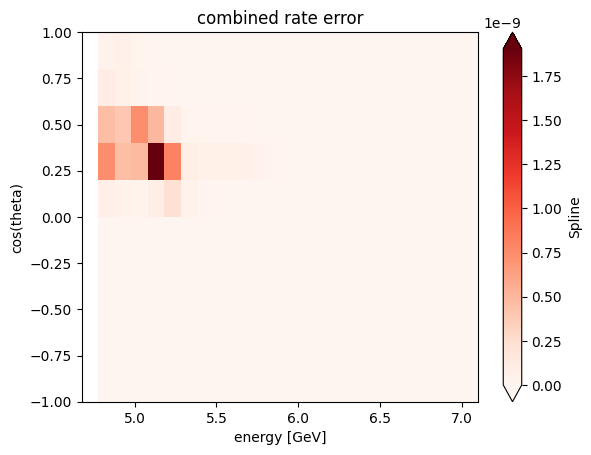

In [37]:
fig, (ax1) = plt.subplots(1, 1)
ax1.set_title("combined rate error")

# plot
X_plot, Y_plot = np.meshgrid(bins_analysis_loge, bins_analysis_cos)
pm = ax1.pcolormesh(X_plot, Y_plot, integrated_rate_error.T, vmin=0, cmap="Reds")
plt.colorbar(pm, label="Spline", extend='both')

# setup figure
ax1.set_xlabel("energy [GeV]")
ax1.set_ylabel("cos(theta)")
ax1.set_xlim(bins_loge[0], bins_loge[-1])
plt.show()

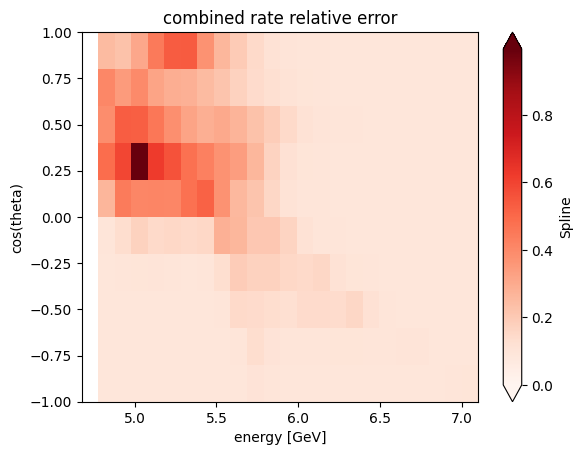

In [38]:
# new figure
fig, (ax1) = plt.subplots(1, 1)
ax1.set_title("combined rate relative error")

# plot
X_plot, Y_plot = np.meshgrid(bins_analysis_loge, bins_analysis_cos)
pm = ax1.pcolormesh(X_plot, Y_plot, integrated_rate.T/integrated_rate_error.T, vmin=0, cmap="Reds")
plt.colorbar(pm, label="Spline", extend='both')

# setup figure
ax1.set_xlabel("energy [GeV]")
ax1.set_ylabel("cos(theta)")
ax1.set_xlim(bins_loge[0], bins_loge[-1])
plt.show()

In [35]:
y

array([8.11081795e-24, 4.70699649e-21, 1.73388858e-18, 4.85229136e-16,
       2.11503815e-13, 7.63255461e-11, 3.99705871e-09, 3.77836180e-10,
       4.11663884e-11, 2.13830425e-11])

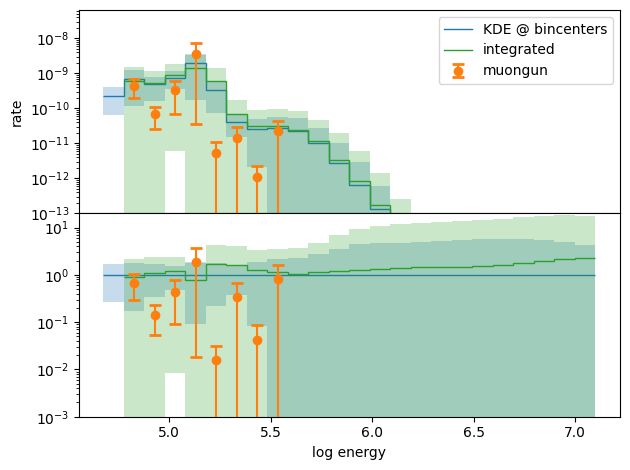

In [39]:
# new figure
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

# KDE
y = np.sum(rate*factor, axis=0)
yerror = np.sqrt(np.sum((rate_error*factor)**2, axis=0))
plot_hist_band(ax1, hist=y, bins=bins_loge, yerror=yerror, color="C0", label="KDE @ bincenters")
plot_ratio_band(ax2, hist=y, bins=bins_loge, yerror=yerror, hist_baseline=y, color="C0")

# muongun
hist, hist_error = make_hist_error(np.log10(reco_energy), bins=bins_loge, weights=weights)
plot_data_hist_errorbar(ax1, hist=hist, bins=bins_loge, yerror=hist_error, color="C1", label="muongun", marker="o")
plot_data_ratio_errorbar(ax2, hist=hist, bins=bins_loge, yerror=hist_error, hist_baseline=y, color="C1", marker="o")

# integrated KDE
y_int = np.sum(integrated_rate, axis=1)
yerror_int = np.sqrt(np.sum(integrated_rate_error**2, axis=1))
plot_hist_band(ax1, hist=y_int, bins=bins_analysis_loge, yerror=yerror_int, color="C2", label="integrated")
plot_ratio_band(ax2, hist=y_int, bins=bins_analysis_loge, yerror=yerror_int, hist_baseline=y[1:], color="C2")

# fine kde
# plot_hist_band(ax1, hist=np.sum(rate_fine.T, axis=1), bins=spline_binning_x, yerror=0, color="C3", label="fine kde")


ax1.legend()
plt.xlabel("log energy")
ax1.set_ylabel("rate")
ax1.set_yscale("log")
# ax2.set_ylim(0, 4)
ax2.set_ylim(1e-3, None)
ax1.set_ylim(1e-13, None)
ax2.set_yscale("log")

# show
fig.tight_layout()
fig.subplots_adjust(hspace=0.0)
plt.show()

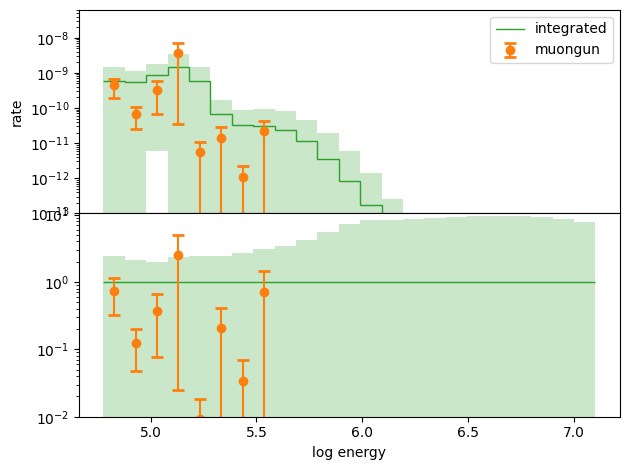

In [40]:
# new figure
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

# integrated KDE
y_int = np.sum(integrated_rate, axis=1)
yerror_int = np.sqrt(np.sum(integrated_rate_error**2, axis=1))
plot_hist_band(ax1, hist=y_int, bins=bins_analysis_loge, yerror=yerror_int, color="C2", label="integrated")
plot_ratio_band(ax2, hist=y_int, bins=bins_analysis_loge, yerror=yerror_int, hist_baseline=y_int, color="C2")

# muongun
hist, hist_error = make_hist_error(np.log10(reco_energy), bins=bins_loge, weights=weights)
plot_data_hist_errorbar(ax1, hist=hist[1:], bins=bins_loge[1:], yerror=hist_error[1:], color="C1", label="muongun", marker="o")
plot_data_ratio_errorbar(ax2, hist=hist[1:], bins=bins_loge[1:], yerror=hist_error[1:], hist_baseline=y_int, color="C1", marker="o")


# fine kde
# plot_hist_band(ax1, hist=np.sum(rate_fine.T, axis=1), bins=spline_binning_x, yerror=0, color="C3", label="fine kde")


ax1.legend()
plt.xlabel("log energy")
ax1.set_ylabel("rate")
ax1.set_yscale("log")
# ax2.set_ylim(0, 2)
ax2.set_ylim(1e-2, None)
ax1.set_ylim(1e-13, None)
ax2.set_yscale("log")

# show
fig.tight_layout()
fig.subplots_adjust(hspace=0.0)
plt.show()

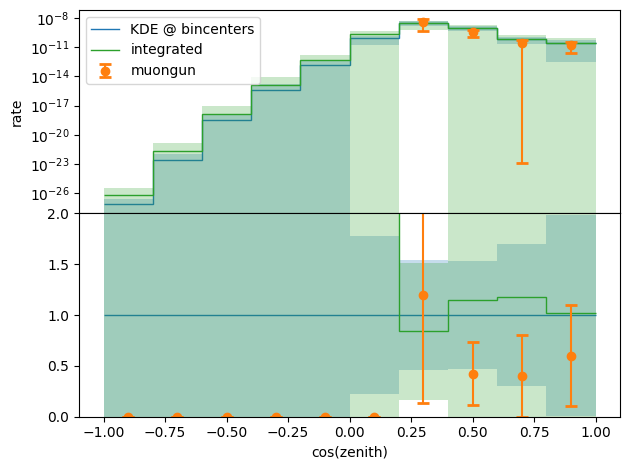

In [41]:
# new figure
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

# KDE
y = np.sum(rate*factor, axis=1)
yerror = np.sqrt(np.sum((rate_error*factor)**2, axis=1))
plot_hist_band(ax1, hist=y, bins=bins_cos, yerror=yerror, color="C0", label="KDE @ bincenters")
plot_ratio_band(ax2, hist=y, bins=bins_cos, yerror=yerror, hist_baseline=y, color="C0")

# muongun
hist, hist_error = make_hist_error(np.cos(reco_zenith)[reco_energy>=1000.], bins=bins_cos, weights=weights[reco_energy>=1000.])
plot_data_hist_errorbar(ax1, hist=hist, bins=bins_cos, yerror=hist_error, color="C1", label="muongun", marker="o")
plot_data_ratio_errorbar(ax2, hist=hist, bins=bins_cos, yerror=hist_error, hist_baseline=y, color="C1", marker="o")

# integrated KDE
y_int = np.sum(integrated_rate, axis=0)
yerror_int = np.sqrt(np.sum(integrated_rate_error**2, axis=0))
plot_hist_band(ax1, hist=y_int, bins=bins_analysis_cos, yerror=yerror_int, color="C2", label="integrated")
plot_ratio_band(ax2, hist=y_int, bins=bins_analysis_cos, yerror=yerror_int, hist_baseline=y, color="C2")

# fine kde
# plot_hist_band(ax1, hist=np.sum(rate_fine.T, axis=0), bins=spline_binning_y, yerror=0, color="C3", label="fine kde")


ax1.legend()
plt.xlabel("cos(zenith)")
ax1.set_ylabel("rate")
ax1.set_yscale("log")
ax2.set_ylim(0, 2)

# show
fig.tight_layout()
fig.subplots_adjust(hspace=0.0)
plt.show()

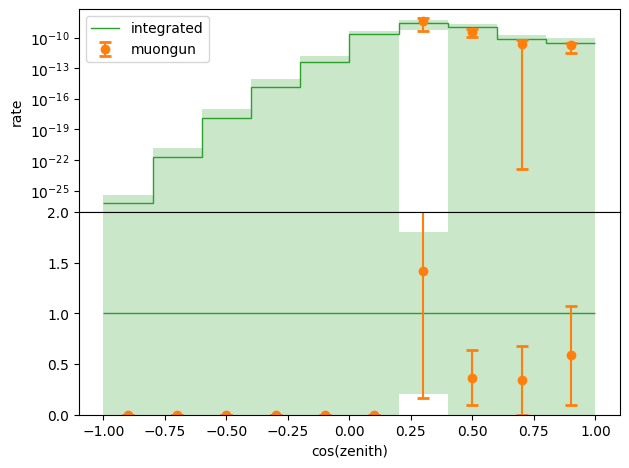

In [42]:
# new figure
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)


# integrated KDE
y_int = np.sum(integrated_rate, axis=0)
yerror_int = np.sqrt(np.sum(integrated_rate_error**2, axis=0))
plot_hist_band(ax1, hist=y_int, bins=bins_analysis_cos, yerror=yerror_int, color="C2", label="integrated")
plot_ratio_band(ax2, hist=y_int, bins=bins_analysis_cos, yerror=yerror_int, hist_baseline=y_int, color="C2")

# muongun
hist, hist_error = make_hist_error(np.cos(reco_zenith)[reco_energy>=1000.], bins=bins_cos, weights=weights[reco_energy>=1000.])
plot_data_hist_errorbar(ax1, hist=hist, bins=bins_cos, yerror=hist_error, color="C1", label="muongun", marker="o")
plot_data_ratio_errorbar(ax2, hist=hist, bins=bins_cos, yerror=hist_error, hist_baseline=y_int, color="C1", marker="o")


ax1.legend()
plt.xlabel("cos(zenith)")
ax1.set_ylabel("rate")
ax1.set_yscale("log")
ax2.set_ylim(0, 2)

# show
fig.tight_layout()
fig.subplots_adjust(hspace=0.0)
plt.show()

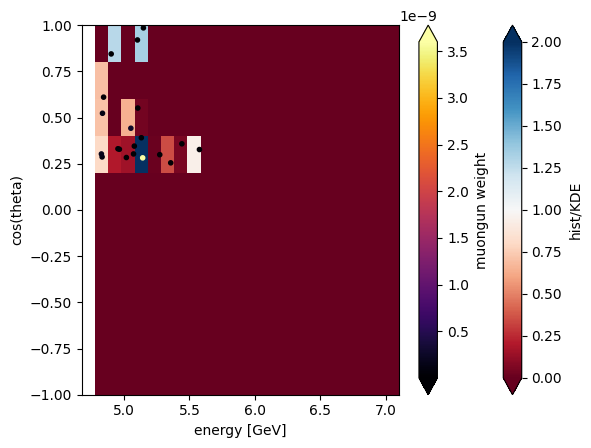

In [43]:
# new figure
fig, (ax1) = plt.subplots(1, 1)

# muongun hist
hist, _, _ = np.histogram2d(
    np.log10(reco_energy),
    np.cos(reco_zenith),
    weights=weights,
    bins=(bins_loge[1:], bins_cos),
)

# plot
X_plot, Y_plot = np.meshgrid(bins_loge[1:], bins_cos)
pm = ax1.pcolormesh(X_plot, Y_plot, hist.T/(integrated_rate.T), cmap="RdBu", vmin=0, vmax=2)
plt.colorbar(pm, label="hist/KDE", extend='both')

pc = ax1.scatter(
    x=np.log10(reco_energy),
    y=np.cos(reco_zenith),
    c=weights,
    cmap="inferno",
    marker="."
)
plt.colorbar(pc, label="muongun weight", extend='both')

# setup figure
ax1.set_xlabel("energy [GeV]")
ax1.set_ylabel("cos(theta)")
ax1.set_xlim(bins_loge[0], bins_loge[-1])
plt.show()

In [48]:
# set path
outfile_path = "/data/ana/Diffuse/GlobalFit_Flavor/NNMFit_Configs/override/MuonGun/Tracks_KDE.pickle"

to_dump = {
    "description" : "KDE for MuonGun generated using ####",
    
    
    "total_rate" : weights.sum(),
    
    "template" : np.fliplr(integrated_rate).flatten(),
    "template_fluctuation" : np.fliplr(integrated_rate_error).flatten(),
    
    # binning
    "energy_bins" : 10**bins_analysis_loge,
    
    "energy_bins_centers_log" : bins_analysis_loge_centers,
    "zenith_bins" : bins_analysis_cos,
    "zenith_bins_centers" : bins_analysis_cos_centers,
}
print(to_dump)

print(sum(np.fliplr(integrated_rate).flatten()))
print(sum(np.fliplr(integrated_rate).flatten())*365*24*3600)

{'description': 'KDE for MuonGun generated using ####', 'total_rate': 4.513981856934444e-09, 'template': array([8.75358543e-12, 3.75791857e-11, 1.78530347e-10, 3.59823207e-10,
       1.86302030e-11, 5.98049011e-14, 1.28170542e-17, 8.13674695e-23,
       5.03475261e-29, 1.04755960e-35, 1.09589260e-11, 2.31995493e-11,
       2.11965749e-10, 2.70999935e-10, 1.91577200e-11, 5.48045552e-14,
       1.63442695e-17, 4.63029524e-22, 1.18457748e-27, 4.75109412e-33,
       5.25646261e-12, 9.71386200e-12, 3.93163129e-10, 4.75242702e-10,
       1.15786792e-11, 6.45919967e-14, 3.37913827e-17, 1.87430022e-21,
       6.01163696e-26, 7.88225305e-31, 2.33140130e-12, 4.45752840e-12,
       2.24254150e-10, 1.19165208e-09, 3.70652339e-11, 3.29235863e-14,
       4.05294112e-17, 1.94902657e-20, 2.37955696e-24, 3.39945710e-29,
       1.20748279e-12, 1.49045310e-12, 3.65817436e-11, 4.53113652e-10,
       9.38571870e-11, 3.18039770e-14, 1.69720094e-16, 1.96119086e-19,
       2.60826801e-23, 3.86408629e-28, 4.43

In [42]:
import pickle
pickle.dump(to_dump, open(outfile_path, "wb"))